# TD-error clipping — 3 conditions x 2 seeds: retrain, training curves & inference
Retrain the pretrained checkpoints under three TD clips (`-severe`, `+severe`, `no clip`) for seeds `[0, 64]`, then plot seed-averaged training curves, representative nutrient trajectories, and multi-inference (seeds x 15, pooled) reward / distance / signed-error / calories-per-day.

In [1]:
# ── Imports ───────────────────────────────────────────────────────────────
import os, json, pickle, warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from agents.ppo import PPOAgent

%matplotlib inline
plt.rcParams['figure.dpi'] = 110
print('Imports OK')

Imports OK


/Users/charithapalika/Desktop/Lab projects/Appetite modelling/FoodRL/FoodRL_cleaned_copies/utils/utils.py:3: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


## 1. Config

In [2]:
# ── Config ────────────────────────────────────────────────────────────────
BASE_CKPT_DIR = 'results/training_checkpoints'   # pretrained base checkpoints live here
CKPT_NAME     = 'last'                            # base ckpt to retrain from ('last' matches existing retrain_500ep)
SEEDS         = [0, 7, 27, 42, 64, 100, 107, 1997, 2003, 2026]                           # retrain from these pretrained seeds

# del-lim conditions: negative-severe, positive-severe, no clip.
# The positive and negative clips are configured INDEPENDENTLY, so the two
# one-sided conditions may use DIFFERENT magnitudes (each run still clips a
# single side; the sign of the del-lim selects which side — see ppo._compute_gae).
SEVERE_NEG = 1e-4          # magnitude of the negative-severe (lower) clip
SEVERE_POS = 1e-5          # magnitude of the positive-severe (upper) clip
CONDITIONS = [(f'-severe (-{SEVERE_NEG:g})', -SEVERE_NEG),
              (f'+severe (+{SEVERE_POS:g})',  SEVERE_POS),
              ('no clip',                     None)]
COND_COLORS = {CONDITIONS[0][0]: 'teal', CONDITIONS[1][0]: 'darkorange', CONDITIONS[2][0]: 'slategray'}

RETRAIN_EPISODES = 500
N_INFERENCE      = 20         # inference rollouts PER SEED (pooled -> len(SEEDS) x 15 per condition)
DETERMINISTIC    = True

TRAIN_KW = dict(rollout_steps=256, ppo_epochs=4, minibatch_size=64, shared_ac_lr=1e-4)

PLOT_DIR = 'results/plots_td_clip_retrain'
os.makedirs(PLOT_DIR, exist_ok=True)

# ── Retrained-model store (shared with td_clip_retrain_sweep) ──────────────
RETRAIN_ROOT     = 'results/retrain_500ep'   # <tag>/checkpoints_retrain_<seed>/
CHECKPOINT_EVERY = 100                        # periodic save cadence during retrain
os.makedirs(RETRAIN_ROOT, exist_ok=True)

def dl_tag(dl):
    """del-lim -> folder name (matches td_clip_retrain_sweep)."""
    if dl is None or dl == 0:
        return 'noclip'
    return f'{"pos" if dl > 0 else "neg"}_{abs(float(dl)):g}'

def seed_ckpt_dir(dl, seed):
    return os.path.join(RETRAIN_ROOT, dl_tag(dl), f'checkpoints_retrain_{seed}')

def dl_label(dl):
    return 'no clip' if (dl is None or dl == 0) else f'{"+" if dl > 0 else "-"}{abs(float(dl)):g}'

print('Conditions    :', [(l, dl) for l, dl in CONDITIONS])
print('Seeds         :', SEEDS)
print(f'Retrain       : {RETRAIN_EPISODES} eps | inference {N_INFERENCE}/seed '
      f'-> {len(SEEDS) * N_INFERENCE} pooled sims/condition')
print(f'Total retrains: {len(CONDITIONS) * len(SEEDS)}  ({len(CONDITIONS)} conds x {len(SEEDS)} seeds)')

Conditions    : [('-severe (-0.0001)', -0.0001), ('+severe (+1e-05)', 1e-05), ('no clip', None)]
Seeds         : [0, 7, 27, 42, 64, 100, 107, 1997, 2003, 2026]
Retrain       : 500 eps | inference 20/seed -> 200 pooled sims/condition
Total retrains: 30  (3 conds x 10 seeds)


## 2. Training — retrain each (condition, seed) or reuse saved checkpoints

In [3]:
# ── TRAINING — retrain each (condition, seed), or REUSE an existing checkpoint ──
#   • if results/retrain_500ep/<tag>/checkpoints_retrain_<seed>/ already has a
#     trained model  -> reuse it (no retraining)
#   • else -> retrain RETRAIN_EPISODES from the base checkpoint, saving every
#     CHECKPOINT_EVERY episodes + a final checkpoint + training_log.npz
#   Training logs are loaded from disk into RESULTS[label]['train'] for plotting.
import time

RESULTS = {}
for label, dl in CONDITIONS:
    RESULTS[label] = {'limit_delta': dl, 'train': {}, 'ckpt_dirs': {}}
    for seed in SEEDS:
        sd   = seed_ckpt_dir(dl, seed)
        meta = os.path.join(sd, 'ppo_agent_last_meta.json')
        if os.path.exists(meta):
            print(f'  REUSE   {label:18s} seed {seed}: {sd}')
        else:
            src_meta = os.path.join(BASE_CKPT_DIR, f'checkpoints_{seed}',
                                    f'ppo_agent_{CKPT_NAME}_meta.json')
            if not os.path.exists(src_meta):
                print(f'  SKIP    {label:18s} seed {seed}: no base checkpoint {src_meta}')
                continue
            print(f'  RETRAIN {label:18s} seed {seed}: {dl_tag(dl)} (dl={dl}) ...', end=' ', flush=True)
            t0 = time.time()
            agent = PPOAgent.from_checkpoint(src_meta, device='cpu')
            agent.args['limit_delta'] = dl
            ckpt_dir = os.path.join(RETRAIN_ROOT, dl_tag(dl), 'checkpoints_retrain')
            agent.train(num_episodes=RETRAIN_EPISODES, log_wandb=False, printing=False,
                        checkpoint_every=CHECKPOINT_EVERY, checkpoint_dir=ckpt_dir, **TRAIN_KW)
            prefix  = agent.save_final(ckpt_dir, log_wandb=False)   # -> checkpoints_retrain_<seed>/
            out_dir = os.path.dirname(prefix)
            agent.save_training_log(os.path.join(out_dir, 'training_log.npz'))
            with open(os.path.join(out_dir, 'retrain_info.json'), 'w') as f:
                json.dump({'seed': seed, 'limit_delta': dl, 'del_lim_tag': dl_tag(dl),
                           'source_ckpt': src_meta, 'retrain_episodes': RETRAIN_EPISODES,
                           'train_kw': TRAIN_KW}, f, indent=2)
            print(f'done ({time.time()-t0:.0f}s)')
        RESULTS[label]['ckpt_dirs'][seed] = sd
        # load training log from disk (works for both reused and freshly retrained)
        tl = os.path.join(sd, 'training_log.npz')
        if os.path.exists(tl):
            z = np.load(tl)
            RESULTS[label]['train'][seed] = {k: np.asarray(z[k]) for k in z.files}

print('\nReady for inference:',
      {l: sorted(RESULTS[l]['ckpt_dirs']) for l in RESULTS})


  REUSE   -severe (-0.0001)  seed 0: results/retrain_500ep/neg_0.0001/checkpoints_retrain_0
  REUSE   -severe (-0.0001)  seed 7: results/retrain_500ep/neg_0.0001/checkpoints_retrain_7
  REUSE   -severe (-0.0001)  seed 27: results/retrain_500ep/neg_0.0001/checkpoints_retrain_27
  REUSE   -severe (-0.0001)  seed 42: results/retrain_500ep/neg_0.0001/checkpoints_retrain_42
  REUSE   -severe (-0.0001)  seed 64: results/retrain_500ep/neg_0.0001/checkpoints_retrain_64
  REUSE   -severe (-0.0001)  seed 100: results/retrain_500ep/neg_0.0001/checkpoints_retrain_100
  REUSE   -severe (-0.0001)  seed 107: results/retrain_500ep/neg_0.0001/checkpoints_retrain_107
  REUSE   -severe (-0.0001)  seed 1997: results/retrain_500ep/neg_0.0001/checkpoints_retrain_1997
  REUSE   -severe (-0.0001)  seed 2003: results/retrain_500ep/neg_0.0001/checkpoints_retrain_2003
  REUSE   -severe (-0.0001)  seed 2026: results/retrain_500ep/neg_0.0001/checkpoints_retrain_2026
  REUSE   +severe (+1e-05)   seed 0: results/ret

## 2b. Inference — load trained models, run rollouts (keeps every episode)

In [35]:
# ── INFERENCE — load each trained model from disk, run N rollouts, keep ALL episodes ──
from analysis.latent_analysis import capture_phy_bottleneck_shadow_data

def _sleep_windows(awake):
    wins, in_s, st = [], False, 0
    for t, a in enumerate(awake):
        if not a and not in_s: in_s, st = True, t
        elif a and in_s: in_s = False; wins.append((st, t))
    if in_s: wins.append((st, len(awake)))
    return wins

def run_inference(agent, env, n_eps):
    """Run n_eps rollouts; return pooled per-step metric stacks + EVERY episode's
       material (z / phy / awake / eat), so any (seed, ep) can be chosen later."""
    n_nut = env.num_nutrients
    names = list(env.nutrient_names)
    tgt, low, high = env._norm_targets, env._norm_target_low, env._norm_target_high
    _z, _t, ep_idx, m = capture_phy_bottleneck_shadow_data(
        agent, env, n_episodes=n_eps, deterministic=DETERMINISTIC,
        network='actor', shadow_names=list(env.shadow_nutrient_names))
    phy   = np.asarray(m['phy_state'])[:, :n_nut]
    rew   = np.asarray(m['reward'])
    awake = np.asarray(m['is_awake']).astype(bool)
    cal   = np.asarray(m['calories_cumulative'])
    signed = (np.minimum(0.0, phy - low[None]) + np.maximum(0.0, phy - high[None])).mean(1)
    dist   = np.linalg.norm(phy - tgt[None], axis=1)
    ate    = (np.asarray(m['action_sum']) > 0) & awake
    cyc    = env.cycle_length

    eps = list(range(n_eps))
    T   = min(int((ep_idx == e).sum()) for e in eps)
    st  = lambda v: np.stack([v[ep_idx == e][:T] for e in eps])

    per_day = []
    for e in eps:
        ce  = cal[ep_idx == e]; inc = np.clip(np.diff(ce, prepend=0.0), 0.0, None)
        day = np.arange(len(ce)) // cyc
        per_day.append(np.array([inc[day == d].sum() for d in range(int(day.max()) + 1)]))
    Dmax = max(len(v) for v in per_day)
    calmat = np.full((n_eps, Dmax), np.nan)
    for e, v in enumerate(per_day): calmat[e, :len(v)] = v

    eps_data = []
    for e in eps:
        me = ep_idx == e
        eat_e = np.where(ate[me][:T])[0]
        eps_data.append({'ep': e, 'ret': float(rew[me].sum()),
                         'food': int(eat_e.size),               # food items eaten (in first T steps)
                         'cal': float(per_day[e].sum()),        # total calories this episode (kcal)
                         'z': _z[me][:T], 'phy': phy[me][:T],
                         'awake': awake[me][:T].astype(int),
                         'eat_steps': eat_e})
    return {
        'reward_steps': st(rew), 'dist_steps': st(dist), 'signed_steps': st(signed),
        'cal_per_day': calmat, 'awake0': awake[ep_idx == 0][:T].astype(int),
        'T': int(T), 'cycle_length': int(cyc), 'names': names,
        'minmax': {nm: (float(env._nutrient_mins[nm]), float(env._nutrient_maxs[nm])) for nm in names},
        'low': np.asarray(low), 'high': np.asarray(high), 'tgt': np.asarray(tgt),
        'eps_data': eps_data,
    }

for label, dl in CONDITIONS:
    R = RESULTS.get(label)
    if not R or not R['ckpt_dirs']:
        continue
    R['seed_infer'] = {}
    for seed, sd in R['ckpt_dirs'].items():
        agent = PPOAgent.from_checkpoint(os.path.join(sd, 'ppo_agent_ep300_meta.json'), device='cpu')
        R['seed_infer'][seed] = run_inference(agent, agent.env, N_INFERENCE)
        print(f'  infer {label:18s} seed {seed}: {N_INFERENCE} eps')

    si = R['seed_infer']
    T  = min(d['T'] for d in si.values())
    cat = lambda k: np.concatenate([d[k][:, :T] for d in si.values()], axis=0)
    Dmax = max(d['cal_per_day'].shape[1] for d in si.values())
    cals = []
    for d in si.values():
        c = d['cal_per_day']
        if c.shape[1] < Dmax: c = np.pad(c, ((0, 0), (0, Dmax - c.shape[1])), constant_values=np.nan)
        cals.append(c)
    ref = next(iter(si.values()))
    R['reps'] = [{'seed': seed, **ed} for seed, d in si.items() for ed in d['eps_data']]
    R['infer'] = {
        'reward_steps': cat('reward_steps'), 'dist_steps': cat('dist_steps'),
        'signed_steps': cat('signed_steps'), 'cal_per_day': np.concatenate(cals, axis=0),
        'awake0': ref['awake0'][:T], 'T': int(T), 'cycle_length': ref['cycle_length'],
        'names': ref['names'], 'minmax': ref['minmax'],
        'low': ref['low'], 'high': ref['high'], 'tgt': ref['tgt'],
    }

def apply_rep(label, seed=None, ep=None):
    """Set RESULTS[label]['infer'] rep_* from a chosen (seed, ep); None -> best-return."""
    R = RESULTS[label]; reps = R['reps']; T = R['infer']['T']
    if seed is None or ep is None:
        best = max(reps, key=lambda r: r['ret'])
    else:
        cand = [r for r in reps if r['seed'] == seed and r['ep'] == ep]
        if not cand:
            print(f"  [{label}] no (seed={seed}, ep={ep}) — using best-return.")
            best = max(reps, key=lambda r: r['ret'])
        else:
            best = cand[0]
    I = R['infer']
    I['rep_traj']      = best['phy'][:T]
    I['rep_z']         = best['z'][:T]
    I['rep_awake']     = np.asarray(best['awake'])[:T]
    I['rep_eat_steps'] = best['eat_steps'][best['eat_steps'] < T]
    I['rep_return']    = best['ret']
    I['rep_seed']      = best['seed']
    I['rep_ep']        = best['ep']
    return best

# default representative = best-return (overridden in the next cell)
for label, dl in CONDITIONS:
    if 'infer' in RESULTS.get(label, {}):
        b = apply_rep(label)
        print(f"  rep {label:18s}: default best-return  seed={b['seed']}  ep={b['ep']}  return={b['ret']:.2f}")


[FoodEnv] Loading  'glucose'  from  'food_dataset/serum_glucose.csv'
           min=70.0758  max=142.5123   foods=19   time_points=500
[FoodEnv] Loading  'peptides'  from  'food_dataset/small_peptides_absorbed.csv'
           min=0.0000  max=0.0018   foods=19   time_points=500
[FoodEnv] Loading  'fatty_acids'  from  'food_dataset/fatty_acids_absorbed.csv'
           min=0.0000  max=0.0007   foods=19   time_points=500
[FoodEnv] Ready — 19 foods | 3 time-series nutrients | 0 cumulative nutrients
[FoodEnv] Loading shadow nutrient 'fullness'  from  'food_dataset/fullness.csv'
[FoodEnv] Loading shadow nutrient 'hunger'  from  'food_dataset/hunger.csv'
[FoodEnv] Loading shadow nutrient 'cck'  from  'food_dataset/cck.csv'
[FoodEnv] Loading shadow nutrient 'ghrelin'  from  'food_dataset/ghrelin.csv'
[FoodEnv] Loading shadow nutrient 'glp_1'  from  'food_dataset/glp_1.csv'
[FoodEnv] Loading shadow nutrient 'pyy'  from  'food_dataset/pyy.csv'
[FoodEnv] Shadow nutrients ready — 6 signal(s): ['ful

## 2c. Choose representative (seed, episode) per condition

In [36]:
CONDITIONS

[('-severe (-0.0001)', -0.0001),
 ('+severe (+1e-05)', 1e-05),
 ('no clip', None)]

In [62]:
# ── CHOOSE REPRESENTATIVE (seed, episode) per condition for the rep plots ──
# The table lists the highest-return rollouts per condition. Pick a (seed, ep)
# to pin the representative used by the nutrient-trajectory (below) and by
# Fig 5.3 / 5.7 in plotting_main.ipynb. Leave a case as None -> best-return.
for label, dl in CONDITIONS:
    R = RESULTS.get(label, {})
    if 'reps' not in R:
        continue
    print(f"\n{label}   (T={R['infer']['T']})")
    print('    seed    ep    return     food     cal(kcal)')
    for r in sorted(R['reps'], key=lambda r: (r['seed'], r['ep'])):
        food = r.get('food', len(r['eat_steps'])); cal = r.get('cal', float('nan'))
        print(f"    {r['seed']:>4}  {r['ep']:>4}   {r['ret']:8.2f}   {food:>6}   {cal:9.1f}")

# ▼▼▼  EDIT: pin (seed, ep) per case, or leave None for best-return  ▼▼▼
REP_CHOICE = {label: None for label, _ in CONDITIONS}
REP_CHOICE['-severe (-0.0001)'] = (2003, 0) #(2003, 3) #LAST
REP_CHOICE['+severe (+1e-05)'] = (2003, 0) #(2003,11) #LAST

# e.g.  REP_CHOICE['no clip'] = (0, 3)
# ▲▲▲ ─────────────────────────────────────────────────────────── ▲▲▲

print('\nApplied representatives:')
for label, choice in REP_CHOICE.items():
    # print(label, choice)
    if label not in RESULTS or 'infer' not in RESULTS[label]:
        continue
    seed, ep = choice if isinstance(choice, (tuple, list)) else (None, None)
    b = apply_rep(label, seed, ep)
    print(f"  {label:18s} -> seed={b['seed']}  ep={b['ep']}  return={b['ret']:.2f}")



-severe (-0.0001)   (T=432)
    seed    ep    return     food     cal(kcal)
       0     0    -257.57       59     19578.1
       0     1    -341.53       72     21019.2
       0     2    -994.55      100     32724.5
       0     3   -1196.85      103     37355.0
       0     4    -419.87       72     25095.4
       0     5    -689.40       87     29737.2
       0     6    -600.89       84     26408.1
       0     7   -2200.56      131     44210.3
       0     8    -395.77       77     24988.3
       0     9    -212.25       58     19070.9
       0    10    -659.78       87     28554.3
       0    11    -435.53       72     22774.0
       0    12    -599.52       84     25397.6
       0    13    -335.81       66     23405.4
       0    14   -1047.91      110     34940.7
       0    15    -340.45       66     20168.3
       0    16    -689.22       89     34311.1
       0    17    -501.64       74     25184.9
       0    18    -368.09       80     23982.4
       0    19    -794.26     

In [63]:
CONDITIONS

[('-severe (-0.0001)', -0.0001),
 ('+severe (+1e-05)', 1e-05),
 ('no clip', None)]

## 3. Training curves — return / distance / consumption (mean +/- SE across seeds)

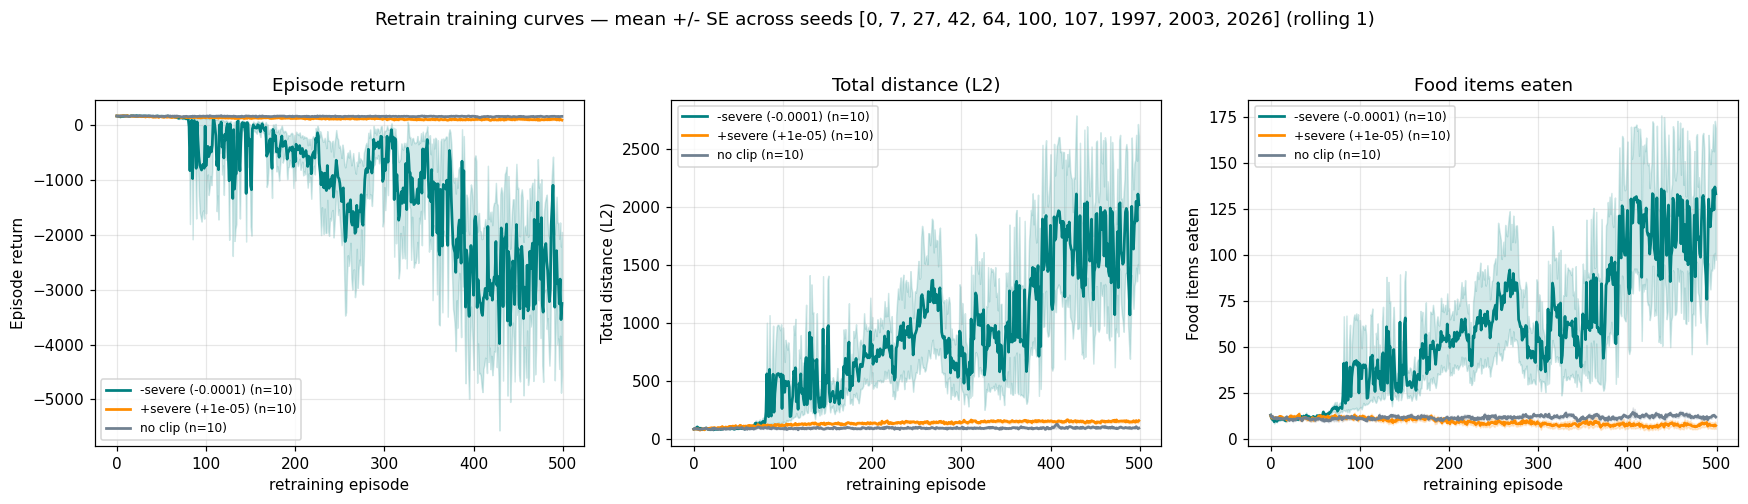

Saved results/plots_td_clip_retrain/retrain_training_curves.png


In [64]:
# ── Training curves — return / distance / consumption (mean +/- SE across seeds) ─
TRAIN_METRICS = [('reward', 'Episode return'), ('distance', 'Total distance (L2)'),
                 ('consumption', 'Food items eaten')]
ROLL = 1

def _rmean(x, w):
    x = np.asarray(x, float)
    return x if len(x) < w else np.convolve(x, np.ones(w) / w, mode='valid')

fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
for label, dl in CONDITIONS:
    logs = RESULTS.get(label, {}).get('train', {})
    if not logs:
        continue
    col = COND_COLORS[label]
    for ax, (key, ylab) in zip(axes, TRAIN_METRICS):
        arrs = [np.asarray(l[key], float) for l in logs.values() if key in l]
        if not arrs:
            continue
        Tm = min(len(a) for a in arrs)
        M  = np.stack([a[:Tm] for a in arrs])            # (n_seeds, T)
        mu = M.mean(0)
        se = M.std(0, ddof=1) / np.sqrt(M.shape[0]) if M.shape[0] > 1 else np.zeros(Tm)
        mu_r, se_r = _rmean(mu, ROLL), _rmean(se, ROLL)
        x = np.arange(len(mu))[len(mu) - len(mu_r):]
        ax.plot(x, mu_r, lw=1.8, color=col, label=f'{label} (n={M.shape[0]})')
        ax.fill_between(x, mu_r - se_r, mu_r + se_r, color=col, alpha=0.18)
for ax, (key, ylab) in zip(axes, TRAIN_METRICS):
    ax.set_title(ylab); ax.set_xlabel('retraining episode'); ax.set_ylabel(ylab)
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
fig.suptitle(f'Retrain training curves — mean +/- SE across seeds {SEEDS} (rolling {ROLL})',
             y=1.03, fontsize=12)
fig.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, 'retrain_training_curves.png'), bbox_inches='tight')
plt.show()
print('Saved', os.path.join(PLOT_DIR, 'retrain_training_curves.png'))

## 4. Nutrient trajectories — representative rollout per condition

In [65]:
# quick peek at one condition's inference dict
list(RESULTS[CONDITIONS[0][0]]['infer'].keys())

['reward_steps',
 'dist_steps',
 'signed_steps',
 'cal_per_day',
 'awake0',
 'T',
 'cycle_length',
 'names',
 'minmax',
 'low',
 'high',
 'tgt',
 'rep_traj',
 'rep_z',
 'rep_awake',
 'rep_eat_steps',
 'rep_return',
 'rep_seed',
 'rep_ep']

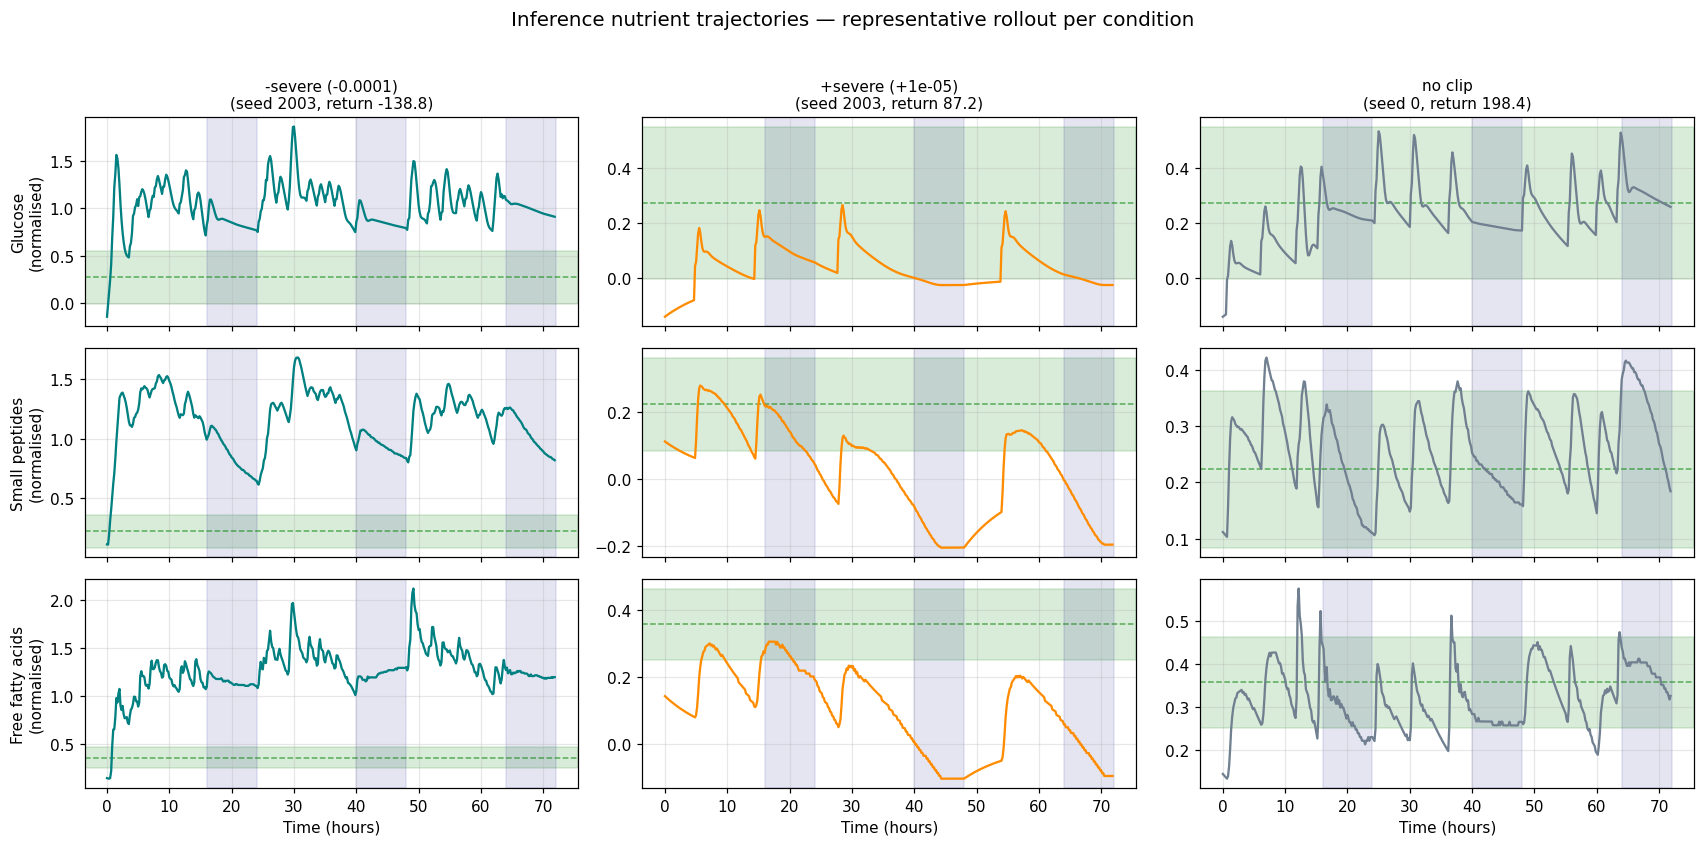

Saved results/plots_td_clip_retrain/inference_nutrient_trajectories.png


In [66]:
# ── Nutrient trajectories — representative rollout per condition ───────────
# Rows = glucose / peptides / fatty acids ; columns = condition.
NUT_ORDER = ['glucose', 'peptides', 'fatty_acids']
NUT_NICE  = {'glucose': 'Glucose', 'peptides': 'Small peptides', 'fatty_acids': 'Free fatty acids'}

conds = [(l, dl) for l, dl in CONDITIONS if 'infer' in RESULTS.get(l, {})]
if not conds:
    print('No inference results — run the retrain cell first.')
else:
    nrow = len([n for n in NUT_ORDER if n in RESULTS[conds[0][0]]['infer']['names']])
    fig, axes = plt.subplots(nrow, len(conds), figsize=(5.2 * len(conds), 2.5 * nrow),
                             sharex=True, squeeze=False)
    for cj, (label, dl) in enumerate(conds):
        I = RESULTS[label]['infer']
        names = I['names']; traj = I['rep_traj']; low, high, tgt = I['low'], I['high'], I['tgt']
        sph = I['cycle_length'] / 24.0                    # steps per hour (day = 24h cycle)
        hours = np.arange(traj.shape[0]) / sph
        wins  = _sleep_windows(np.asarray(I['rep_awake']).astype(bool))
        rows  = [n for n in NUT_ORDER if n in names]
        for ri, nm in enumerate(rows):
            i = names.index(nm); ax = axes[ri][cj]
            ax.axhspan(low[i], high[i], alpha=0.15, color='green', label='Target band')
            ax.axhline(tgt[i], ls='--', color='green', lw=1.0, alpha=0.6)
            ax.plot(hours, traj[:, i], color=COND_COLORS[label], lw=1.5)
            for k, (ws, we) in enumerate(wins):
                ax.axvspan(ws / sph, we / sph, alpha=0.10, color='navy')
            ax.grid(alpha=0.3)
            if cj == 0:
                ax.set_ylabel(NUT_NICE[nm] + '\n(normalised)')
            if ri == 0:
                ax.set_title(f'{label}\n(seed {I["rep_seed"]}, return {I["rep_return"]:.1f})', fontsize=10)
            if ri == nrow - 1:
                ax.set_xlabel('Time (hours)')
    fig.suptitle('Inference nutrient trajectories — representative rollout per condition',
                 y=1.02, fontsize=13)
    fig.tight_layout()
    fig.savefig(os.path.join(PLOT_DIR, 'inference_nutrient_trajectories.png'), bbox_inches='tight')
    plt.show()
    print('Saved', os.path.join(PLOT_DIR, 'inference_nutrient_trajectories.png'))

## 5. Inference metrics per condition — reward / distance / signed-error + calories/day

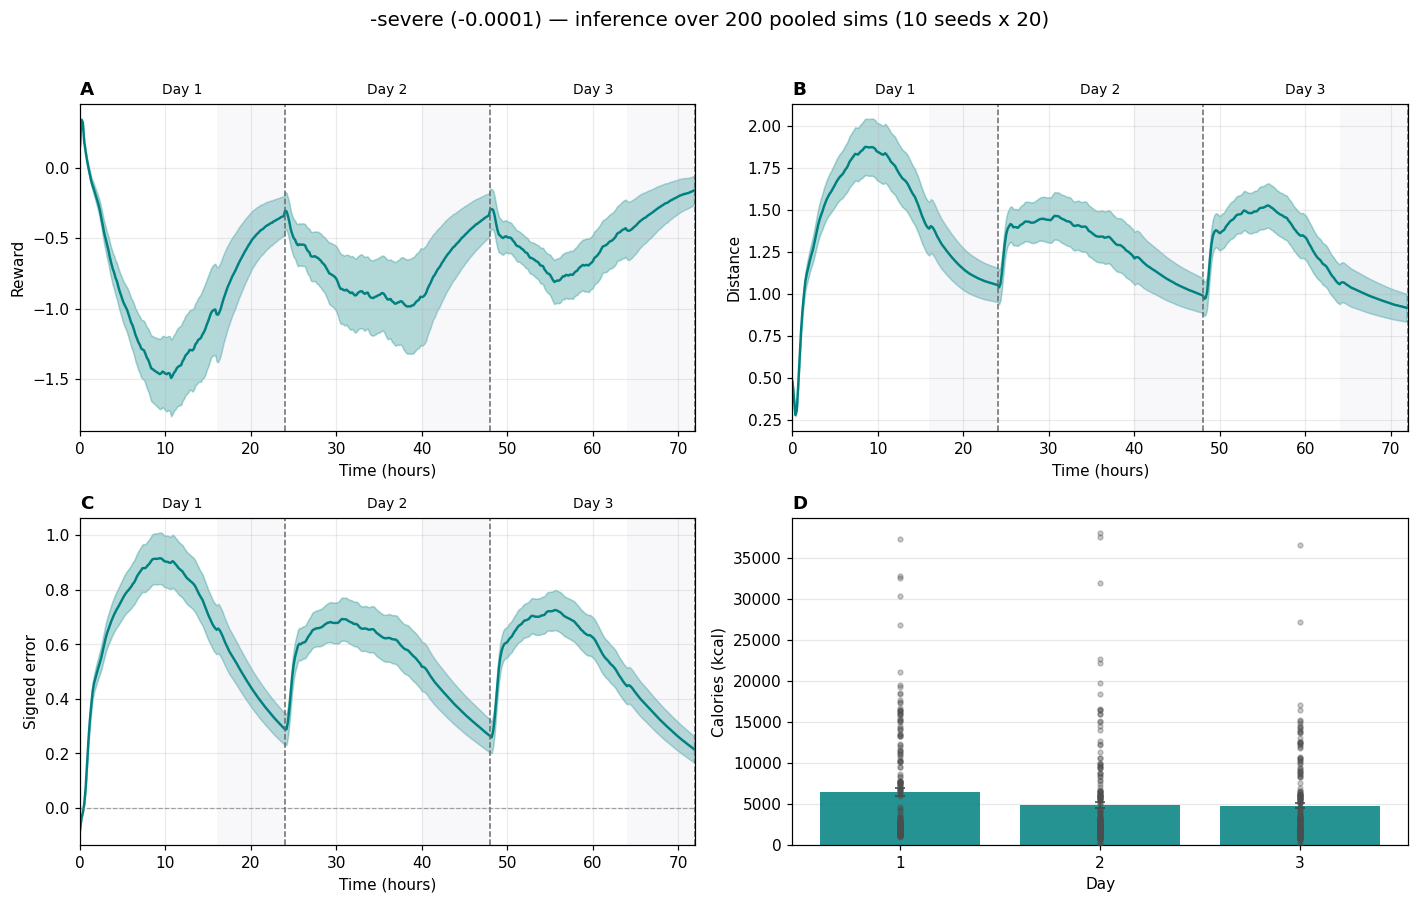

Saved results/plots_td_clip_retrain/inference_metrics_negsevere_neg0.0001.png


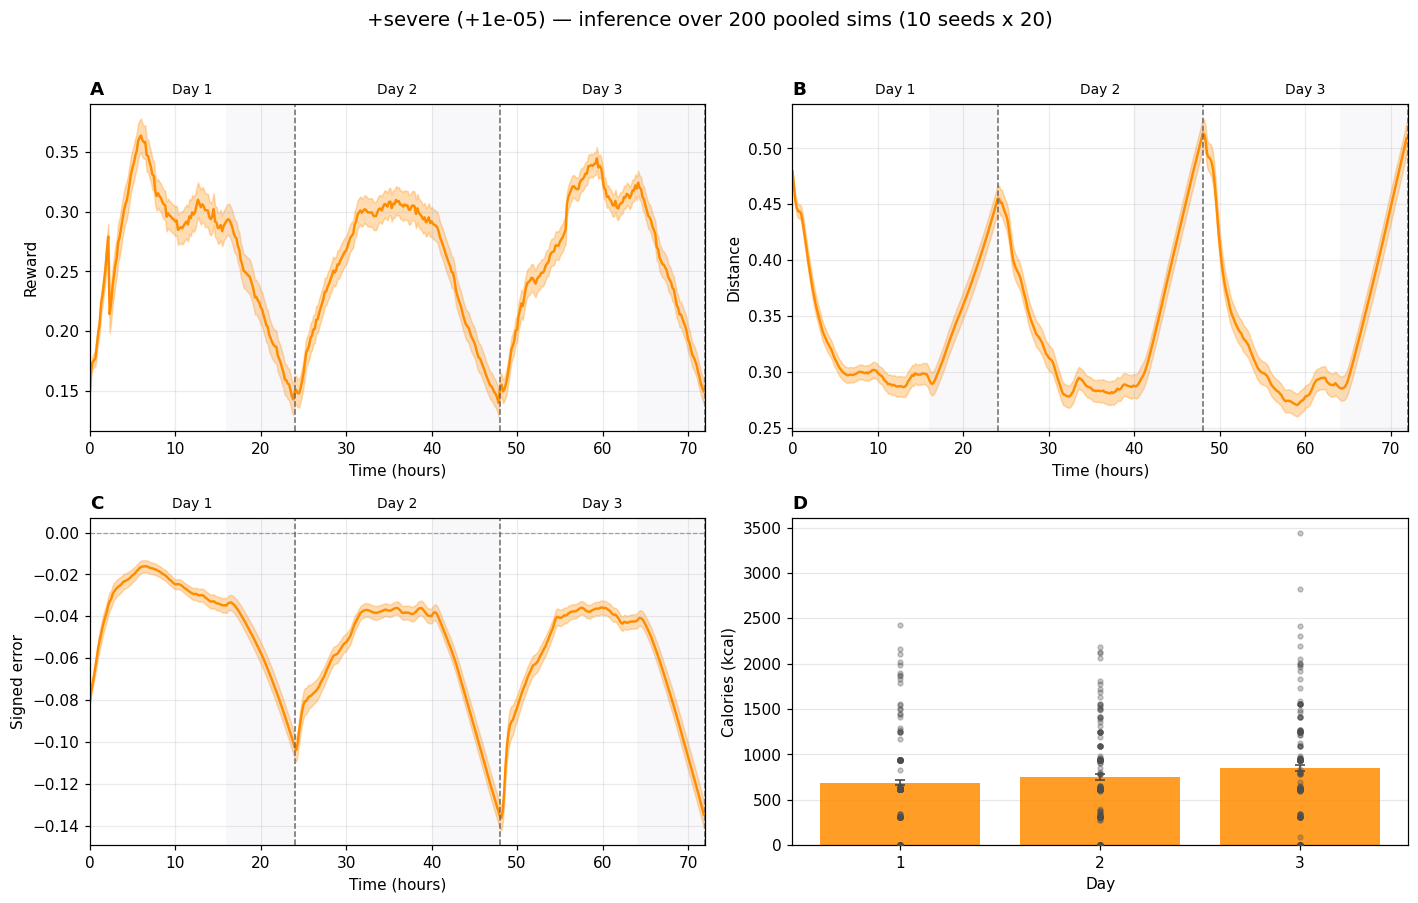

Saved results/plots_td_clip_retrain/inference_metrics_possevere_pos1eneg05.png


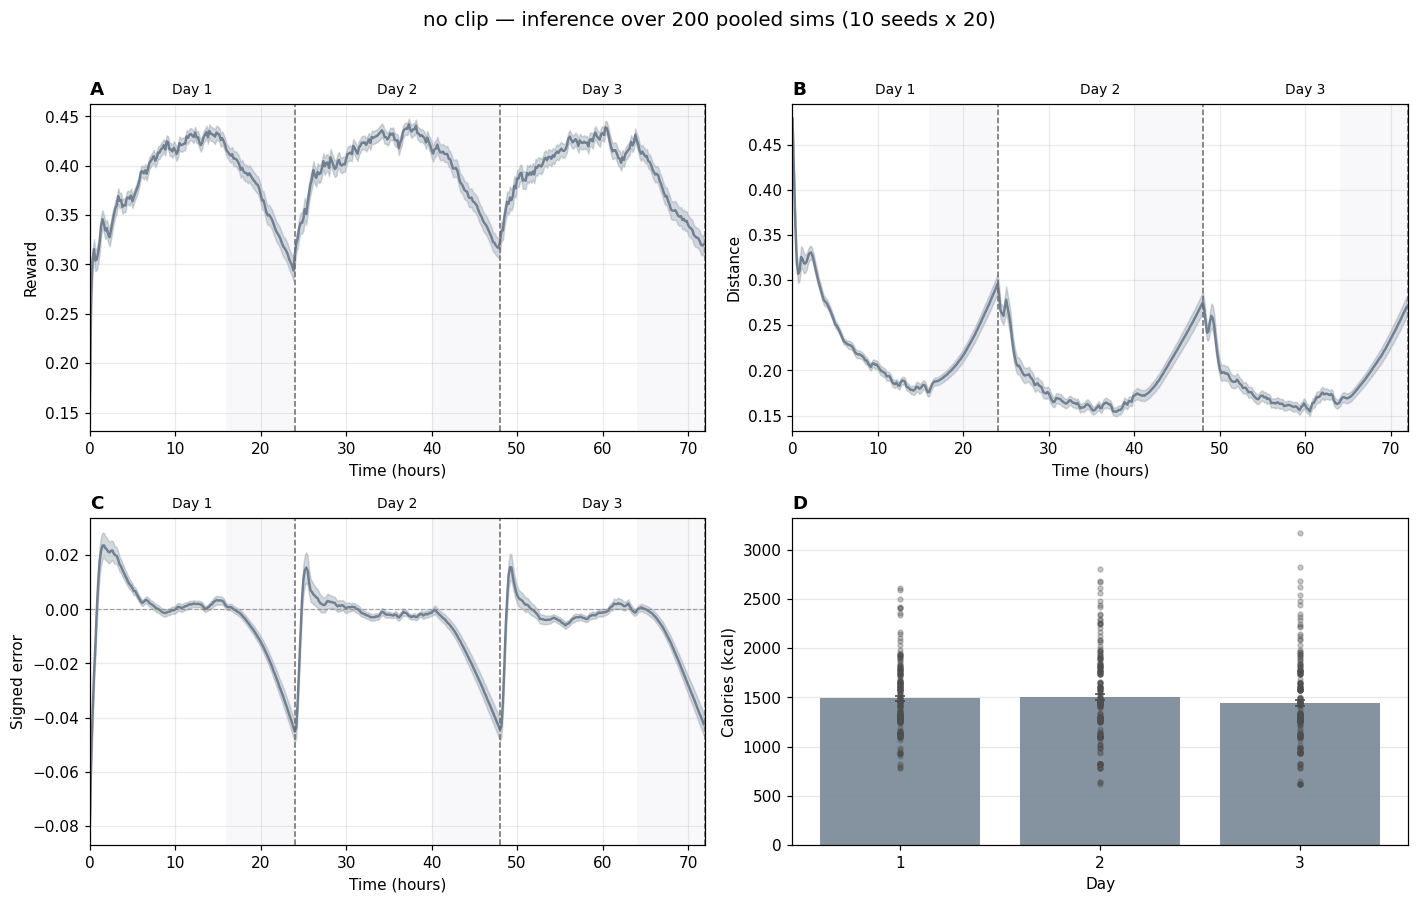

Saved results/plots_td_clip_retrain/inference_metrics_no_clip.png


In [67]:
# ── Inference metrics per condition (ref-style 2x2): per-step reward /
#    distance / signed-error (mean +/- SE over pooled sims) + calories/day ──
def _shade_days(ax, wins, sph, n_days, cyc):
    for (ws, we) in wins:
        ax.axvspan(ws / sph, we / sph, alpha=0.12, color='#c9c9e6', lw=0)
    for d in range(1, n_days + 1):
        ax.axvline(d * cyc / sph, color='dimgray', lw=1.0, ls='--')

def _msem(M):
    mu = M.mean(0)
    se = M.std(0, ddof=1) / np.sqrt(M.shape[0]) if M.shape[0] > 1 else np.zeros(M.shape[1])
    return mu, se

for label, dl in [(l, d) for l, d in CONDITIONS if 'infer' in RESULTS.get(l, {})]:
    I = RESULTS[label]['infer']
    T = I['T']; cyc = I['cycle_length']; sph = cyc / 24.0
    hours = np.arange(T) / sph
    wins  = _sleep_windows(np.asarray(I['awake0']).astype(bool))
    n_days = int(np.ceil(T / cyc))
    col = COND_COLORS[label]

    fig, axes = plt.subplots(2, 2, figsize=(13, 8))
    panels = [(axes[0, 0], I['reward_steps'], 'Reward',       'A'),
              (axes[0, 1], I['dist_steps'],   'Distance',     'B'),
              (axes[1, 0], I['signed_steps'], 'Signed error', 'C')]
    for ax, M, ylab, tag in panels:
        mu, se = _msem(M[:, :T])
        ax.plot(hours, mu, color=col, lw=1.6)
        ax.fill_between(hours, mu - se, mu + se, color=col, alpha=0.30)
        if ylab == 'Signed error':
            ax.axhline(0, color='grey', lw=0.8, ls='--', alpha=0.7)
        _shade_days(ax, wins, sph, n_days, cyc)
        for d in range(n_days):
            ax.text((d + 0.5) * cyc / sph, 1.02, f'Day {d+1}',
                    transform=ax.get_xaxis_transform(), ha='center', va='bottom', fontsize=9)
        ax.set_ylabel(ylab); ax.set_xlabel('Time (hours)'); ax.set_xlim(0, T / sph)
        ax.set_title(tag, loc='left', fontweight='bold'); ax.grid(alpha=0.25)

    # D: calories per day (bars mean +/- SEM + per-sim scatter)
    ax = axes[1, 1]
    cm = I['cal_per_day']; nD = cm.shape[1]; xd = np.arange(1, nD + 1)
    cnt = np.sum(~np.isnan(cm), 0)
    dmean = np.nanmean(cm, 0)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        dstd = np.nanstd(cm, 0, ddof=1)
    dsem = np.where(cnt > 1, dstd / np.sqrt(np.maximum(cnt, 1)), 0.0)
    ax.bar(xd, dmean, yerr=dsem, capsize=3, color=col, alpha=0.85,
           error_kw=dict(lw=1.0, ecolor='0.25'))
    for s in range(cm.shape[0]):
        ax.scatter(xd, cm[s], s=10, color='0.3', alpha=0.3, zorder=3)
    ax.set_xticks(xd); ax.set_xlabel('Day'); ax.set_ylabel('Calories (kcal)')
    ax.set_title('D', loc='left', fontweight='bold')
    ax.grid(alpha=0.3, axis='y'); ax.set_axisbelow(True)

    n_sims = I['reward_steps'].shape[0]
    fig.suptitle(f'{label} — inference over {n_sims} pooled sims '
                 f'({len(SEEDS)} seeds x {N_INFERENCE})', y=1.02, fontsize=13)
    fig.tight_layout()
    slug = label.replace(' ', '_').replace('(', '').replace(')', '').replace('+', 'pos').replace('-', 'neg')
    fname = f'inference_metrics_{slug}.png'
    fig.savefig(os.path.join(PLOT_DIR, fname), bbox_inches='tight'); plt.show()
    print('Saved', os.path.join(PLOT_DIR, fname))

## 6. Save all plotting data

In [68]:
# ── Save all data behind the figures (pkl) ────────────────────────────────
# Slim the per-condition results: keep limit_delta, training logs, and the
# pooled 'infer' dict (with chosen rep_*). Drop the heavy per-episode 'reps'
# and 'seed_infer' (only needed live in this notebook for choosing reps).
_slim = {}
for label, dl in CONDITIONS:
    R = RESULTS.get(label, {})
    if 'infer' not in R:
        continue
    _slim[label] = {'limit_delta': R.get('limit_delta', dl),
                    'train': R.get('train', {}),
                    'infer': R['infer']}
bundle = {
    'conditions':       CONDITIONS,
    'seeds':            SEEDS,
    'severe_neg':       SEVERE_NEG,
    'severe_pos':       SEVERE_POS,
    'retrain_episodes': RETRAIN_EPISODES,
    'n_inference':      N_INFERENCE,
    'train_kw':         TRAIN_KW,
    'ckpt_name':        CKPT_NAME,
    'rep_choice':       {l: (RESULTS[l]['infer'].get('rep_seed'),
                             RESULTS[l]['infer'].get('rep_ep')) for l in _slim},
    'results':          _slim,
}
_path = os.path.join(PLOT_DIR, 'td_clip_retrain_conditions.pkl')
with open(_path, 'wb') as f:
    pickle.dump(bundle, f, protocol=pickle.HIGHEST_PROTOCOL)
print('Saved', _path)
for label, _ in CONDITIONS:
    R = _slim.get(label, {})
    if 'infer' in R:
        I = R['infer']
        print(f'  {label:18s}: {I["reward_steps"].shape[0]} pooled sims | T={I["T"]} | '
              f'{I["cal_per_day"].shape[1]} days | rep seed={I.get("rep_seed")} ep={I.get("rep_ep")}')

Saved results/plots_td_clip_retrain/td_clip_retrain_conditions.pkl
  -severe (-0.0001) : 200 pooled sims | T=432 | 3 days | rep seed=2003 ep=0
  +severe (+1e-05)  : 200 pooled sims | T=432 | 3 days | rep seed=2003 ep=0
  no clip           : 200 pooled sims | T=432 | 3 days | rep seed=0 ep=19
